# MAE ImageNet-Mini Linear Recoverability Probes

Self-contained notebook: extracts MAE ViT-B/16 features and runs the
full linear-vs-nonlinear probe battery on ImageNet-Mini concepts.

**No CLIP or DINO code is present** — this avoids the function-overwrite
bug in the combined notebook.

In [ ]:
!nvidia-smi
!pip install -q timm scikit-learn matplotlib seaborn torchvision

Wed May 13 01:21:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import sys
import json
import random
import shutil
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import requests
from PIL import Image
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from timm.data import resolve_model_data_config, create_transform
from torchvision.datasets import ImageFolder

warnings.filterwarnings("ignore", message="n_jobs value")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

Using: cuda


## 1. Load MAE Backbone

In [ ]:
MAE_MODEL_NAME = "vit_base_patch16_224.mae"
BACKBONE_NAME = "mae_vit_base_patch16_224"
CACHE_DIR = f"imagenetmini_feature_cache_{BACKBONE_NAME}"  # never collides with CLIP/DINO

mae_model = timm.create_model(
    MAE_MODEL_NAME,
    pretrained=True,
    num_classes=0,       # return features, not logits
    global_pool="token",  # CLS token
).to(device)
mae_model.eval()

data_config = resolve_model_data_config(mae_model)
mae_preprocess = create_transform(**data_config, is_training=False)

print(f"Loaded {BACKBONE_NAME}")
print(f"Feature dim: {mae_model.num_features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loaded mae_vit_base_patch16_224
Feature dim: 768


In [ ]:
@torch.no_grad()
def mae_extract_features(images, batch_size=64, normalize=True):
    """Extract L2-normalised MAE CLS-token features. Returns (N, 768) array."""
    mae_model.eval()
    all_features = []
    for i in tqdm(range(0, len(images), batch_size), desc="Extracting MAE features"):
        batch = images[i : i + batch_size]
        batch_tensors = torch.stack([mae_preprocess(img) for img in batch]).to(device)
        feats = mae_model(batch_tensors)
        if isinstance(feats, (tuple, list)):
            feats = feats[0]
        if feats.ndim == 3:
            feats = feats[:, 0]
        if normalize:
            feats = F.normalize(feats.float(), dim=-1)
        all_features.append(feats.cpu().numpy())
    return np.concatenate(all_features, axis=0)

## 2. Probe Infrastructure (5-Fold CV)

In [ ]:
N_FOLDS = 5


def run_linear_probe_cv(features, labels, n_folds=N_FOLDS, random_state=42):
    """5-fold CV logistic regression. Returns (mean_acc, std_acc, mean_auc, std_auc)."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    acc_scores, auc_scores = [], []
    for train_idx, test_idx in skf.split(features, labels):
        X_train, X_test = features[train_idx], features[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]
        clf = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", random_state=random_state)
        clf.fit(X_train, y_train)
        acc_scores.append(accuracy_score(y_test, clf.predict(X_test)))
        probs = clf.predict_proba(X_test)
        if len(np.unique(labels)) == 2:
            auc_scores.append(roc_auc_score(y_test, probs[:, 1]))
        else:
            auc_scores.append(roc_auc_score(y_test, probs, multi_class="ovr"))
    return np.mean(acc_scores), np.std(acc_scores), np.mean(auc_scores), np.std(auc_scores)


def run_mlp_probe_cv(features, labels, hidden_layers=(128, 64), n_folds=N_FOLDS, random_state=42):
    """5-fold CV MLP probe. Returns (mean_acc, std_acc, mean_auc, std_auc)."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    acc_scores, auc_scores = [], []
    for train_idx, test_idx in skf.split(features, labels):
        X_train, X_test = features[train_idx], features[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]
        clf = MLPClassifier(
            hidden_layer_sizes=hidden_layers, max_iter=1000,
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=20, activation="relu", solver="adam",
            learning_rate="adaptive", random_state=random_state,
        )
        clf.fit(X_train, y_train)
        acc_scores.append(accuracy_score(y_test, clf.predict(X_test)))
        probs = clf.predict_proba(X_test)
        if len(np.unique(labels)) == 2:
            auc_scores.append(roc_auc_score(y_test, probs[:, 1]))
        else:
            auc_scores.append(roc_auc_score(y_test, probs, multi_class="ovr"))
    return np.mean(acc_scores), np.std(acc_scores), np.mean(auc_scores), np.std(auc_scores)


def evaluate_concept(concept_name, features, labels):
    """Full probe battery. Returns dict with all results and linearity gaps."""
    print(f"{'=' * 60}")
    print(f"Concept: {concept_name}")
    print(f"Dataset: {len(labels)} images, {len(np.unique(labels))} classes")
    print(f"Class balance: {dict(zip(*np.unique(labels, return_counts=True)))}")
    print(f"{'=' * 60}")

    lin_acc, lin_acc_std, lin_auc, lin_auc_std = run_linear_probe_cv(features, labels)
    print(f"\nLinear probe (5-fold CV):")
    print(f"  acc: {lin_acc:.3f} +/- {lin_acc_std:.3f}  auc: {lin_auc:.3f} +/- {lin_auc_std:.3f}")

    mlp_configs = {
        "mlp_1layer": (128,),
        "mlp_2layer": (128, 64),
        "mlp_3layer": (128, 64, 32),
    }
    nl_results = {}
    print(f"\nNonlinear probes (5-fold CV):")
    for name, hidden in mlp_configs.items():
        acc, acc_std, auc, auc_std = run_mlp_probe_cv(features, labels, hidden_layers=hidden)
        nl_results[name] = {
            "test_acc": acc, "acc_std": acc_std,
            "test_auc": auc, "auc_std": auc_std,
            "hidden_layers": hidden,
        }
        print(f"  {name} {str(hidden):>15s}  |  acc: {acc:.3f} +/- {acc_std:.3f}  auc: {auc:.3f} +/- {auc_std:.3f}")

    acc_gaps = {n: r["test_acc"] - lin_acc for n, r in nl_results.items()}
    auc_gaps = {n: r["test_auc"] - lin_auc for n, r in nl_results.items()}

    print(f"\n{'─' * 60}")
    print(f"Summary for: {concept_name}")
    print(f"  {'Probe':<20s} {'Acc':>6s} {'AUC':>6s} {'Acc gap':>8s} {'AUC gap':>8s}")
    print(f"  {'linear':<20s} {lin_acc:>6.3f} {lin_auc:>6.3f} {'---':>8s} {'---':>8s}")
    for name, res in nl_results.items():
        print(f"  {name:<20s} {res['test_acc']:>6.3f} {res['test_auc']:>6.3f} {acc_gaps[name]:>+8.3f} {auc_gaps[name]:>+8.3f}")
    print(f"{'─' * 60}\n")

    return {
        "concept": concept_name,
        "linear_test_acc": lin_acc, "linear_acc_std": lin_acc_std,
        "linear_test_auc": lin_auc, "linear_auc_std": lin_auc_std,
        "nonlinear_results": nl_results,
        "acc_gaps": acc_gaps,
        "auc_gaps": auc_gaps,
    }


def mae_test_concept(concept_name, images, labels):
    """Extract MAE features (with caching) and run probe battery."""
    os.makedirs(CACHE_DIR, exist_ok=True)
    cache_path = os.path.join(CACHE_DIR, f"{concept_name}.npz")

    if os.path.exists(cache_path):
        print(f"Loading cached MAE features for '{concept_name}'...")
        data = np.load(cache_path)
        features, labels = data["features"], data["labels"]
    else:
        print(f"Extracting MAE features for '{concept_name}'...")
        features = mae_extract_features(images)
        np.savez(cache_path, features=features, labels=labels)

    result = evaluate_concept(concept_name, features, labels)
    all_results[concept_name] = result
    return result


all_results = {}

## 3. ImageNet-Mini Data Loading

In [ ]:
# ── Kaggle download helpers ──────────────────────────────────

IMAGENETMINI_KAGGLE_DATASET = "ifigotin/imagenetmini-1000"
COLAB_DATA_DIR = Path("/content/data")
LOCAL_DATA_DIR = Path("./data")
IMAGENET_MINI_ROOT_OVERRIDE = None


def _run(cmd):
    print("Running:", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True)


def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False


def _looks_like_imagenetmini_root(path):
    if path is None:
        return False
    return (
        (path / "train").is_dir()
        and (path / "val").is_dir()
        and any((path / "train").iterdir())
        and any((path / "val").iterdir())
    )


def find_imagenetmini_root(search_base=None):
    candidates = []
    if IMAGENET_MINI_ROOT_OVERRIDE:
        candidates.append(Path(IMAGENET_MINI_ROOT_OVERRIDE))
    candidates.extend([
        COLAB_DATA_DIR / "imagenet-mini",
        COLAB_DATA_DIR / "imagenetmini-1000" / "imagenet-mini",
        COLAB_DATA_DIR / "input" / "imagenetmini-1000" / "imagenet-mini",
        Path("/kaggle/input/imagenetmini-1000/imagenet-mini"),
        Path("/kaggle/input/imagenet-mini/imagenet-mini"),
        LOCAL_DATA_DIR / "imagenet-mini",
        Path("./imagenet-mini"),
    ])
    if search_base is not None and search_base.exists():
        candidates.extend([p for p in search_base.rglob("imagenet-mini") if p.is_dir()])
    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser()
        if candidate in seen:
            continue
        seen.add(candidate)
        if _looks_like_imagenetmini_root(candidate):
            return candidate.resolve()
    return None


def install_kaggle_cli():
    try:
        import kaggle  # noqa: F401
        return
    except Exception:
        pass
    _run([sys.executable, "-m", "pip", "install", "-q", "kaggle"])


def ensure_kaggle_credentials():
    print("Using KAGGLE_API_TOKEN from environment.")
    return


def download_imagenetmini_to_colab(force=False):
    data_dir = COLAB_DATA_DIR if _in_colab() else LOCAL_DATA_DIR
    data_dir.mkdir(parents=True, exist_ok=True)
    if not force:
        existing = find_imagenetmini_root(data_dir)
        if existing is not None:
            print(f"ImageNet-Mini already exists at: {existing}")
            return existing
    install_kaggle_cli()
    ensure_kaggle_credentials()
    print(f"Downloading Kaggle dataset {IMAGENETMINI_KAGGLE_DATASET} to {data_dir} ...")
    _run(["kaggle", "datasets", "download", "-d", IMAGENETMINI_KAGGLE_DATASET, "-p", str(data_dir), "--unzip"])
    root = find_imagenetmini_root(data_dir)
    if root is None:
        raise FileNotFoundError(f"Download finished, but no imagenet-mini folder found under {data_dir}.")
    print(f"ImageNet-Mini ready at: {root}")
    return root


IMAGENET_MINI_ROOT = download_imagenetmini_to_colab(force=False)
print("IMAGENET_MINI_ROOT =", IMAGENET_MINI_ROOT)

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
Running: /usr/bin/python3 -m pip install -q kaggle
Using KAGGLE_API_TOKEN from environment.
Running: kaggle datasets download -d ifigotin/imagenetmini-1000 -p /content/data --unzip
ImageNet-Mini ready at: /content/data/imagenet-mini
IMAGENET_MINI_ROOT = /content/data/imagenet-mini


In [ ]:
# ── ImageNet class name resolution ───────────────────────────

def load_imagenet_class_names(class_to_idx):
    try:
        url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
        class_index = requests.get(url, timeout=10).json()
        synset_to_name = {v[0]: v[1].replace("_", " ") for v in class_index.values()}
        if all(s in synset_to_name for s in class_to_idx):
            return {s: synset_to_name[s] for s in class_to_idx}
    except Exception as exc:
        print(f"Could not fetch canonical ImageNet class names: {exc}")
    try:
        from torchvision.models import ResNet50_Weights
        categories = ResNet50_Weights.IMAGENET1K_V2.meta["categories"]
        return {s: categories[idx].replace("_", " ") for s, idx in class_to_idx.items() if idx < len(categories)}
    except Exception as exc:
        print(f"Could not load torchvision ImageNet categories: {exc}")
    print("Falling back to synset ids as class names.")
    return {s: s for s in class_to_idx}


def make_imagenetmini_rows(root=IMAGENET_MINI_ROOT, split="val"):
    split_dir = Path(root) / split
    ds = ImageFolder(str(split_dir))
    class_names = load_imagenet_class_names(ds.class_to_idx)
    rows = []
    for path, class_idx in ds.samples:
        synset = ds.classes[class_idx]
        rows.append({"path": path, "class_idx": int(class_idx), "synset": synset, "name": class_names.get(synset, synset)})
    print(f"{split}: {len(rows)} images, {len(ds.classes)} classes")
    return rows, ds.class_to_idx


def load_imagenetmini_concept(labeler_fn, root=IMAGENET_MINI_ROOT, split="val", max_per_class=500, seed=42):
    rows, _ = make_imagenetmini_rows(root=root, split=split)
    class_rows = {}
    for row in rows:
        label = labeler_fn(row)
        if label is None:
            continue
        class_rows.setdefault(label, []).append(row)
    if len(class_rows) < 2:
        raise ValueError(f"Need at least 2 labels, got {list(class_rows.keys())}")
    min_count = min(len(v) for v in class_rows.values())
    n_per_class = min(min_count, max_per_class)
    if n_per_class < 2:
        raise ValueError(f"Not enough examples per class: {{k: len(v) for k, v in class_rows.items()}}")
    label_values = sorted(class_rows.keys(), key=lambda x: str(x))
    label_to_int = {label: i for i, label in enumerate(label_values)}
    print(f"  Labels: {label_values}, {n_per_class}/class, mapping: {label_to_int}")
    rng = np.random.default_rng(seed)
    images, labels = [], []
    for label in label_values:
        selected = rng.choice(len(class_rows[label]), size=n_per_class, replace=False)
        for pos in selected:
            row = class_rows[label][int(pos)]
            img = Image.open(row["path"]).convert("RGB")
            images.append(img)
            labels.append(label_to_int[label])
    return images, np.array(labels, dtype=np.int64)

## 4. Concept Battery

In [ ]:
def _text(row):
    return row["name"].replace("_", " ").lower()

def _has_any_term(row, terms):
    name = f" {_text(row)} "
    return any(f" {term} " in name or term in name for term in terms)

DOG_TERMS = [
    "dog", "hound", "terrier", "retriever", "spaniel", "shepherd", "setter",
    "poodle", "corgi", "collie", "schnauzer", "mastiff", "husky", "malamute",
    "beagle", "boxer", "chihuahua", "rottweiler", "pinscher", "dachshund",
    "basenji", "pug", "keeshond", "samoyed", "dalmatian", "great dane",
]
CAT_TERMS = ["cat", "tabby", "tiger cat", "persian", "siamese", "egyptian cat"]
BIRD_TERMS = [
    "bird", "cock", "hen", "ostrich", "brambling", "goldfinch", "finch",
    "junco", "indigo bunting", "robin", "bulbul", "jay", "magpie", "chickadee",
    "water ouzel", "kite", "eagle", "vulture", "owl", "goose", "duck",
]
INSECT_TERMS = [
    "bee", "ant", "grasshopper", "cricket", "mantis", "cicada", "leafhopper",
    "dragonfly", "damselfly", "admiral", "ringlet", "monarch", "cabbage butterfly",
    "sulphur butterfly", "lycaenid", "beetle", "fly", "weevil",
]
VEHICLE_TERMS = [
    "car", "truck", "bus", "minibus", "limousine", "jeep", "taxi", "cab",
    "motor scooter", "bicycle", "mountain bike", "moped", "trailer", "wagon",
    "locomotive", "train", "airliner", "airship", "aircraft", "plane", "boat",
    "ship", "vessel", "canoe", "yawl", "catamaran", "trimaran", "fire engine",
    "ambulance", "snowmobile", "go-kart", "tank",
]
FOOD_TERMS = [
    "pizza", "cheeseburger", "hotdog", "burrito", "bagel", "pretzel", "ice cream",
    "ice lolly", "banana", "orange", "lemon", "fig", "pineapple", "pomegranate",
    "carbonara", "guacamole", "consomme", "trifle", "meat loaf", "plate",
]

def imagenet_is_dog(row):
    return 1 if (151 <= row["class_idx"] <= 268 or _has_any_term(row, DOG_TERMS)) else 0

def imagenet_is_bird(row):
    return 1 if (7 <= row["class_idx"] <= 24 or _has_any_term(row, BIRD_TERMS)) else 0

def imagenet_is_vehicle(row):
    return 1 if _has_any_term(row, VEHICLE_TERMS) else 0

def imagenet_dog_vs_cat(row):
    if imagenet_is_dog(row):
        return "dog"
    if _has_any_term(row, CAT_TERMS) or (281 <= row["class_idx"] <= 285):
        return "cat"
    return None

def imagenet_bird_vs_insect(row):
    if imagenet_is_bird(row):
        return "bird"
    if _has_any_term(row, INSECT_TERMS) or (300 <= row["class_idx"] <= 319):
        return "insect"
    return None

def imagenet_animal_vs_vehicle(row):
    is_animal = (
        imagenet_is_dog(row) or imagenet_is_bird(row)
        or _has_any_term(row, CAT_TERMS) or _has_any_term(row, INSECT_TERMS)
        or (281 <= row["class_idx"] <= 319)
    )
    is_vehicle = imagenet_is_vehicle(row)
    if is_animal and not is_vehicle:
        return "animal"
    if is_vehicle and not is_animal:
        return "vehicle"
    return None

def imagenet_supercategory_4way(row):
    matches = []
    if imagenet_is_dog(row): matches.append("dog")
    if imagenet_is_bird(row): matches.append("bird")
    if imagenet_is_vehicle(row): matches.append("vehicle")
    if _has_any_term(row, FOOD_TERMS): matches.append("food")
    return matches[0] if len(matches) == 1 else None


imagenetmini_concept_battery = {
    "imagenetmini_has_dog": imagenet_is_dog,
    "imagenetmini_has_bird": imagenet_is_bird,
    "imagenetmini_has_vehicle": imagenet_is_vehicle,
    "imagenetmini_dog_vs_cat": imagenet_dog_vs_cat,
    "imagenetmini_bird_vs_insect": imagenet_bird_vs_insect,
    "imagenetmini_animal_vs_vehicle": imagenet_animal_vs_vehicle,
    "imagenetmini_supercategory_4way": imagenet_supercategory_4way,
}

## 5. Run Probes

In [ ]:
IMAGENETMINI_SPLIT = "val"
IMAGENETMINI_MAX_PER_CLASS = 500

imagenetmini_result_names = []

for concept_name, labeler in imagenetmini_concept_battery.items():
    print(f"\nLoading ImageNet-Mini concept: {concept_name}")
    images, labels = load_imagenetmini_concept(
        labeler,
        root=IMAGENET_MINI_ROOT,
        split=IMAGENETMINI_SPLIT,
        max_per_class=IMAGENETMINI_MAX_PER_CLASS,
        seed=42,
    )
    mae_test_concept(concept_name, images, labels)
    imagenetmini_result_names.append(concept_name)


Loading ImageNet-Mini concept: imagenetmini_has_dog
val: 3923 images, 1000 classes
  Labels: [0, 1], 442/class, mapping: {0: 0, 1: 1}
Extracting MAE features for 'imagenetmini_has_dog'...


Extracting MAE features:   0%|          | 0/14 [00:00<?, ?it/s]

Concept: imagenetmini_has_dog
Dataset: 884 images, 2 classes
Class balance: {np.int64(0): np.int64(442), np.int64(1): np.int64(442)}

Linear probe (5-fold CV):
  acc: 0.831 +/- 0.029  auc: 0.900 +/- 0.027

Nonlinear probes (5-fold CV):
  mlp_1layer          (128,)  |  acc: 0.914 +/- 0.021  auc: 0.966 +/- 0.015
  mlp_2layer       (128, 64)  |  acc: 0.920 +/- 0.030  auc: 0.970 +/- 0.015
  mlp_3layer   (128, 64, 32)  |  acc: 0.934 +/- 0.022  auc: 0.979 +/- 0.011

────────────────────────────────────────────────────────────
Summary for: imagenetmini_has_dog
  Probe                   Acc    AUC  Acc gap  AUC gap
  linear                0.831  0.900      ---      ---
  mlp_1layer            0.914  0.966   +0.083   +0.066
  mlp_2layer            0.920  0.970   +0.088   +0.070
  mlp_3layer            0.934  0.979   +0.103   +0.079
────────────────────────────────────────────────────────────


Loading ImageNet-Mini concept: imagenetmini_has_bird
val: 3923 images, 1000 classes
  Labels: [0, 1], 

Extracting MAE features:   0%|          | 0/4 [00:00<?, ?it/s]

Concept: imagenetmini_has_bird
Dataset: 212 images, 2 classes
Class balance: {np.int64(0): np.int64(106), np.int64(1): np.int64(106)}

Linear probe (5-fold CV):
  acc: 0.580 +/- 0.069  auc: 0.645 +/- 0.087

Nonlinear probes (5-fold CV):
  mlp_1layer          (128,)  |  acc: 0.703 +/- 0.054  auc: 0.755 +/- 0.048
  mlp_2layer       (128, 64)  |  acc: 0.665 +/- 0.067  auc: 0.745 +/- 0.074
  mlp_3layer   (128, 64, 32)  |  acc: 0.651 +/- 0.079  auc: 0.748 +/- 0.068

────────────────────────────────────────────────────────────
Summary for: imagenetmini_has_bird
  Probe                   Acc    AUC  Acc gap  AUC gap
  linear                0.580  0.645      ---      ---
  mlp_1layer            0.703  0.755   +0.123   +0.110
  mlp_2layer            0.665  0.745   +0.085   +0.101
  mlp_3layer            0.651  0.748   +0.071   +0.103
────────────────────────────────────────────────────────────


Loading ImageNet-Mini concept: imagenetmini_has_vehicle
val: 3923 images, 1000 classes
  Labels: [0,

...

Concept: imagenetmini_bird_vs_insect
Dataset: 212 images, 2 classes
Class balance: {np.int64(0): np.int64(106), np.int64(1): np.int64(106)}

Linear probe (5-fold CV):
  acc: 0.585 +/- 0.050  auc: 0.661 +/- 0.077

Nonlinear probes (5-fold CV):
  mlp_1layer          (128,)  |  acc: 0.675 +/- 0.090  auc: 0.746 +/- 0.066
  mlp_2layer       (128, 64)  |  acc: 0.623 +/- 0.061  auc: 0.704 +/- 0.073
  mlp_3layer   (128, 64, 32)  |  acc: 0.732 +/- 0.106  auc: 0.817 +/- 0.104

────────────────────────────────────────────────────────────
Summary for: imagenetmini_bird_vs_insect
  Probe                   Acc    AUC  Acc gap  AUC gap
  linear                0.585  0.661      ---      ---
  mlp_1layer            0.675  0.746   +0.090   +0.085
  mlp_2layer            0.623  0.704   +0.038   +0.043
  mlp_3layer            0.732  0.817   +0.147   +0.157
────────────────────────────────────────────────────────────


Loading ImageNet-Mini concept: imagenetmini_animal_vs_vehicle
val: 3923 images, 1000 cla

Extracting MAE features:   0%|          | 0/7 [00:00<?, ?it/s]

Concept: imagenetmini_animal_vs_vehicle
Dataset: 434 images, 2 classes
Class balance: {np.int64(0): np.int64(217), np.int64(1): np.int64(217)}

Linear probe (5-fold CV):
  acc: 0.721 +/- 0.053  auc: 0.790 +/- 0.035

Nonlinear probes (5-fold CV):
  mlp_1layer          (128,)  |  acc: 0.855 +/- 0.044  auc: 0.895 +/- 0.063
  mlp_2layer       (128, 64)  |  acc: 0.901 +/- 0.017  auc: 0.962 +/- 0.025
  mlp_3layer   (128, 64, 32)  |  acc: 0.880 +/- 0.057  auc: 0.951 +/- 0.035

────────────────────────────────────────────────────────────
Summary for: imagenetmini_animal_vs_vehicle
  Probe                   Acc    AUC  Acc gap  AUC gap
  linear                0.721  0.790      ---      ---
  mlp_1layer            0.855  0.895   +0.134   +0.106
  mlp_2layer            0.901  0.962   +0.180   +0.172
  mlp_3layer            0.880  0.951   +0.159   +0.161
────────────────────────────────────────────────────────────


Loading ImageNet-Mini concept: imagenetmini_supercategory_4way
val: 3923 images, 1

Extracting MAE features:   0%|          | 0/5 [00:00<?, ?it/s]

Concept: imagenetmini_supercategory_4way
Dataset: 288 images, 4 classes
Class balance: {np.int64(0): np.int64(72), np.int64(1): np.int64(72), np.int64(2): np.int64(72), np.int64(3): np.int64(72)}

Linear probe (5-fold CV):
  acc: 0.496 +/- 0.019  auc: 0.774 +/- 0.046

Nonlinear probes (5-fold CV):
  mlp_1layer          (128,)  |  acc: 0.649 +/- 0.062  auc: 0.863 +/- 0.039
  mlp_2layer       (128, 64)  |  acc: 0.674 +/- 0.103  auc: 0.893 +/- 0.046
  mlp_3layer   (128, 64, 32)  |  acc: 0.760 +/- 0.076  auc: 0.921 +/- 0.035

────────────────────────────────────────────────────────────
Summary for: imagenetmini_supercategory_4way
  Probe                   Acc    AUC  Acc gap  AUC gap
  linear                0.496  0.774      ---      ---
  mlp_1layer            0.649  0.863   +0.153   +0.089
  mlp_2layer            0.674  0.893   +0.178   +0.119
  mlp_3layer            0.760  0.921   +0.264   +0.147
────────────────────────────────────────────────────────────



## 6. Summary Table & Visualization

In [ ]:
imagenet_rows = []
for name in imagenetmini_result_names:
    res = all_results[name]
    best_nl_name, best_nl = max(
        res["nonlinear_results"].items(),
        key=lambda kv: kv[1]["test_auc"],
    )
    imagenet_rows.append({
        "Backbone": BACKBONE_NAME,
        "Concept": name,
        "Linear Acc": res["linear_test_acc"],
        "Linear AUC": res["linear_test_auc"],
        "Best Nonlinear": best_nl_name,
        "Best NL Acc": best_nl["test_acc"],
        "Best NL AUC": best_nl["test_auc"],
        "Acc Gap": best_nl["test_acc"] - res["linear_test_acc"],
        "AUC Gap": best_nl["test_auc"] - res["linear_test_auc"],
    })

mae_df = (
    pd.DataFrame(imagenet_rows)
    .sort_values("AUC Gap", ascending=False)
    .reset_index(drop=True)
)

display(mae_df)
print(mae_df.to_string(index=False, float_format="%.6f"))

# Save CSV
os.makedirs("results", exist_ok=True)
csv_path = f"results/{BACKBONE_NAME}_imagenetmini_linearity_gaps.csv"
mae_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

,Backbone,Concept,Linear Acc,Linear AUC,Best Nonlinear,Best NL Acc,Best NL AUC,Acc Gap,AUC Gap
0,mae_vit_base_patch16_224,imagenetmini_animal_vs_vehicle,0.721224,0.789668,mlp_2layer,0.900909,0.961812,0.179685,0.172145
1,mae_vit_base_patch16_224,imagenetmini_bird_vs_insect,0.585271,0.660627,mlp_3layer,0.731783,0.817192,0.146512,0.156566
2,mae_vit_base_patch16_224,imagenetmini_supercategory_4way,0.496491,0.774081,mlp_3layer,0.760315,0.920896,0.263823,0.146815
3,mae_vit_base_patch16_224,imagenetmini_has_vehicle,0.624365,0.680019,mlp_2layer,0.725235,0.790889,0.100869,0.110871
4,mae_vit_base_patch16_224,imagenetmini_has_bird,0.579956,0.644589,mlp_1layer,0.702547,0.754896,0.122591,0.110307
5,mae_vit_base_patch16_224,imagenetmini_dog_vs_cat,0.616993,0.596605,mlp_3layer,0.650980,0.699691,0.033987,0.103086
6,mae_vit_base_patch16_224,imagenetmini_has_dog,0.831420,0.900255,mlp_3layer,0.934386,0.979322,0.102966,0.079067


                Backbone                         Concept  Linear Acc  Linear AUC Best Nonlinear  Best NL Acc  Best NL AUC  Acc Gap  AUC Gap
mae_vit_base_patch16_224  imagenetmini_animal_vs_vehicle    0.721224    0.789668     mlp_2layer     0.900909     0.961812 0.179685 0.172145
mae_vit_base_patch16_224     imagenetmini_bird_vs_insect    0.585271    0.660627     mlp_3layer     0.731783     0.817192 0.146512 0.156566
mae_vit_base_patch16_224 imagenetmini_supercategory_4way    0.496491    0.774081     mlp_3layer     0.760315     0.920896 0.263823 0.146815
mae_vit_base_patch16_224        imagenetmini_has_vehicle    0.624365    0.680019     mlp_2layer     0.725235     0.790889 0.100869 0.110871
mae_vit_base_patch16_224           imagenetmini_has_bird    0.579956    0.644589     mlp_1layer     0.702547     0.754896 0.122591 0.110307
mae_vit_base_patch16_224         imagenetmini_dog_vs_cat    0.616993    0.596605     mlp_3layer     0.650980     0.699691 0.033987 0.103086
mae_vit_base_patch16

Saved figure.


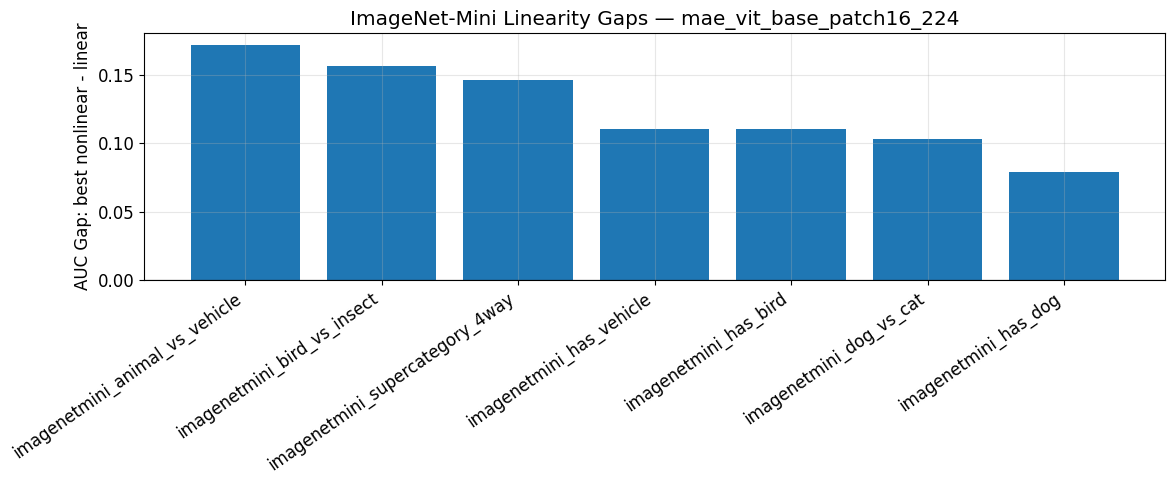

In [ ]:
# ── Bar chart of AUC gaps ────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(mae_df)), mae_df["AUC Gap"])
ax.set_ylabel("AUC Gap: best nonlinear - linear")
ax.set_title(f"ImageNet-Mini Linearity Gaps — {BACKBONE_NAME}")
ax.set_xticks(range(len(mae_df)))
ax.set_xticklabels(mae_df["Concept"], rotation=35, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
fig.savefig(f"figures/{BACKBONE_NAME}_imagenetmini_linearity_gaps.png", dpi=200, bbox_inches="tight")
fig.savefig(f"figures/{BACKBONE_NAME}_imagenetmini_linearity_gaps.pdf", bbox_inches="tight")
print(f"Saved figure.")
plt.show()

In [ ]:
# ── Sanity check: confirm features are NOT 512-dim (CLIP) ───

sample_cache = os.path.join(CACHE_DIR, f"{imagenetmini_result_names[0]}.npz")
if os.path.exists(sample_cache):
    data = np.load(sample_cache)
    print(f"Cached feature shape: {data['features'].shape}")
    print(f"Expected: (N, 768) for MAE ViT-B/16")
    assert data['features'].shape[1] == 768, (
        f"ERROR: feature dim is {data['features'].shape[1]}, not 768. "
        f"These may be CLIP features loaded by mistake!"
    )
    print("OK — features are 768-dim as expected for MAE.")
else:
    print(f"No cache file found at {sample_cache}")

Cached feature shape: (884, 768)
Expected: (N, 768) for MAE ViT-B/16
OK — features are 768-dim as expected for MAE.


In [ ]:
# ============================================================
# Extra deps for CLIP + visualization
# ============================================================

!pip install -q open_clip_torch

import open_clip

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Load CLIP + DINO
# MAE is already loaded earlier in the notebook
# ============================================================

RANDOM_STATE = 42
VIZ_CACHE_DIR = "imagenetmini_viz_cache"
os.makedirs(VIZ_CACHE_DIR, exist_ok=True)

# ---- CLIP ----
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k",
    device=device,
)
clip_model.eval()

# ---- DINO ----
DINO_MODEL_NAME = "vit_base_patch16_224.dino"
dino_model = timm.create_model(
    DINO_MODEL_NAME,
    pretrained=True,
    num_classes=0,
).to(device)
dino_model.eval()

dino_preprocess = create_transform(
    **resolve_model_data_config(dino_model),
    is_training=False,
)

print("Loaded CLIP, MAE, and DINO")
print("CLIP output dim: 512")
print("MAE output dim:", mae_model.num_features)
print("DINO output dim:", dino_model.num_features)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loaded CLIP, MAE, and DINO
CLIP output dim: 512
MAE output dim: 768
DINO output dim: 768


In [ ]:
# ============================================================
# Feature extraction helpers
# ============================================================

@torch.no_grad()
def clip_extract_features(images, batch_size=64, normalize=True):
    clip_model.eval()
    all_features = []

    for i in tqdm(range(0, len(images), batch_size), desc="Extracting CLIP features"):
        batch = images[i : i + batch_size]
        batch_tensors = torch.stack([clip_preprocess(img) for img in batch]).to(device)
        feats = clip_model.encode_image(batch_tensors)

        if normalize:
            feats = F.normalize(feats.float(), dim=-1)

        all_features.append(feats.cpu().numpy())

    return np.concatenate(all_features, axis=0)


@torch.no_grad()
def dino_extract_features(images, batch_size=64, normalize=True):
    dino_model.eval()
    all_features = []

    for i in tqdm(range(0, len(images), batch_size), desc="Extracting DINO features"):
        batch = images[i : i + batch_size]
        batch_tensors = torch.stack([dino_preprocess(img) for img in batch]).to(device)
        feats = dino_model(batch_tensors)

        if isinstance(feats, (tuple, list)):
            feats = feats[0]
        if feats.ndim == 3:
            feats = feats[:, 0]

        if normalize:
            feats = F.normalize(feats.float(), dim=-1)

        all_features.append(feats.cpu().numpy())

    return np.concatenate(all_features, axis=0)

In [ ]:
# ============================================================
# Load ImageNet-Mini 4-way supercategory concept
# ============================================================

VIZ_CONCEPT_NAME = "imagenetmini_supercategory_4way"
VIZ_CLASS_NAMES = ["bird", "dog", "food", "vehicle"]

viz_images, viz_labels = load_imagenetmini_concept(
    imagenetmini_concept_battery[VIZ_CONCEPT_NAME],
    root=IMAGENET_MINI_ROOT,
    split="val",
    max_per_class=500,
    seed=42,
)

print("Loaded concept:", VIZ_CONCEPT_NAME)
print("Num images:", len(viz_images))
print("Class counts:", dict(zip(*np.unique(viz_labels, return_counts=True))))

val: 3923 images, 1000 classes
  Labels: ['bird', 'dog', 'food', 'vehicle'], 72/class, mapping: {'bird': 0, 'dog': 1, 'food': 2, 'vehicle': 3}
Loaded concept: imagenetmini_supercategory_4way
Num images: 288
Class counts: {np.int64(0): np.int64(72), np.int64(1): np.int64(72), np.int64(2): np.int64(72), np.int64(3): np.int64(72)}


In [ ]:
# ============================================================
# Extract or load cached features for visualization
# ============================================================

viz_cache_path = os.path.join(VIZ_CACHE_DIR, f"{VIZ_CONCEPT_NAME}_clip_mae_dino.npz")

if os.path.exists(viz_cache_path):
    print(f"Loading cached visualization features from {viz_cache_path}")
    data = np.load(viz_cache_path, allow_pickle=True)

    features_by_model = {
        "CLIP": data["clip"],
        "MAE": data["mae"],
        "DINO": data["dino"],
    }
else:
    features_by_model = {
        "CLIP": clip_extract_features(viz_images),
        "MAE": mae_extract_features(viz_images),
        "DINO": dino_extract_features(viz_images),
    }

    np.savez(
        viz_cache_path,
        clip=features_by_model["CLIP"],
        mae=features_by_model["MAE"],
        dino=features_by_model["DINO"],
    )
    print(f"Saved visualization features to {viz_cache_path}")

for model_name, feats in features_by_model.items():
    print(model_name, feats.shape)

Extracting CLIP features:   0%|          | 0/5 [00:00<?, ?it/s]

Extracting MAE features:   0%|          | 0/5 [00:00<?, ?it/s]

Extracting DINO features:   0%|          | 0/5 [00:00<?, ?it/s]

Saved visualization features to imagenetmini_viz_cache/imagenetmini_supercategory_4way_clip_mae_dino.npz
CLIP (288, 512)
MAE (288, 768)
DINO (288, 768)


In [ ]:
# ============================================================
# Plotting helper
# ============================================================

from matplotlib.lines import Line2D

def plot_2d_embeddings_grid(
    embeddings_by_model,
    labels,
    title,
    class_names,
    save_path=None,
):
    labels = np.array(labels).astype(int)
    model_names = list(embeddings_by_model.keys())

    fig, axes = plt.subplots(
        1,
        len(model_names),
        figsize=(6 * len(model_names), 5),
        squeeze=False,
    )
    axes = axes[0]

    cmap = plt.cm.get_cmap("viridis", len(class_names))
    handles = []

    for ax, model_name in zip(axes, model_names):
        z = embeddings_by_model[model_name]

        sc = ax.scatter(
            z[:, 0],
            z[:, 1],
            c=labels,
            cmap=cmap,
            s=22,
            alpha=0.85,
        )

        try:
            sil = silhouette_score(z, labels)
            sil_text = f"silhouette = {sil:.3f}"
        except Exception:
            sil_text = "silhouette = N/A"

        ax.set_title(f"{model_name}\n{sil_text}")
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")

    # Manual legend with class names
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='', label=class_names[i],
               markerfacecolor=cmap(i), markeredgecolor='none', markersize=8)
        for i in range(len(class_names))
    ]

    fig.legend(
        handles=legend_handles,
        title="Class",
        loc="center right",
        bbox_to_anchor=(1.02, 0.5),
    )

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.92, 0.93])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()

Running Kernel PCA for CLIP
Running Kernel PCA for MAE
Running Kernel PCA for DINO


/tmp/ipykernel_4804/848350423.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(class_names))


Saved figure to: results/imagenetmini_supercategory_4way_kernel_pca_clip_mae_dino.png


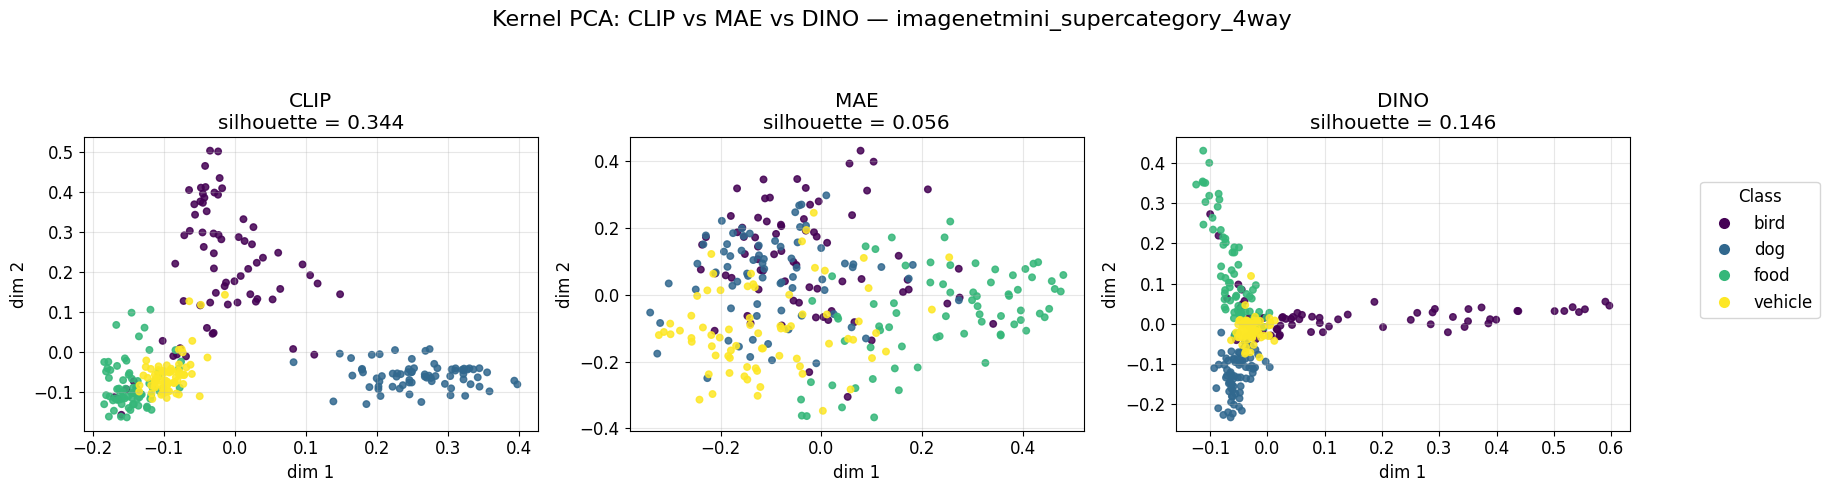

In [ ]:
# ============================================================
# Kernel PCA
# ============================================================

def run_kernel_pca(features, n_components=2, gamma=None):
    x = StandardScaler().fit_transform(features)

    kpca = KernelPCA(
        n_components=n_components,
        kernel="rbf",
        gamma=gamma,                 # None => sklearn default = 1 / n_features
        eigen_solver="arpack",
        random_state=RANDOM_STATE,
    )

    z = kpca.fit_transform(x)
    return z


kernel_pca_embeddings = {}

for model_name, feats in features_by_model.items():
    print(f"Running Kernel PCA for {model_name}")
    kernel_pca_embeddings[model_name] = run_kernel_pca(
        feats,
        n_components=2,
        gamma=None,
    )

plot_2d_embeddings_grid(
    kernel_pca_embeddings,
    viz_labels,
    title=f"Kernel PCA: CLIP vs MAE vs DINO — {VIZ_CONCEPT_NAME}",
    class_names=VIZ_CLASS_NAMES,
    save_path=f"results/{VIZ_CONCEPT_NAME}_kernel_pca_clip_mae_dino.png",
)

Running t-SNE for CLIP
Running t-SNE for MAE
Running t-SNE for DINO


/tmp/ipykernel_4804/848350423.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", len(class_names))


Saved figure to: results/imagenetmini_supercategory_4way_tsne_clip_mae_dino.png


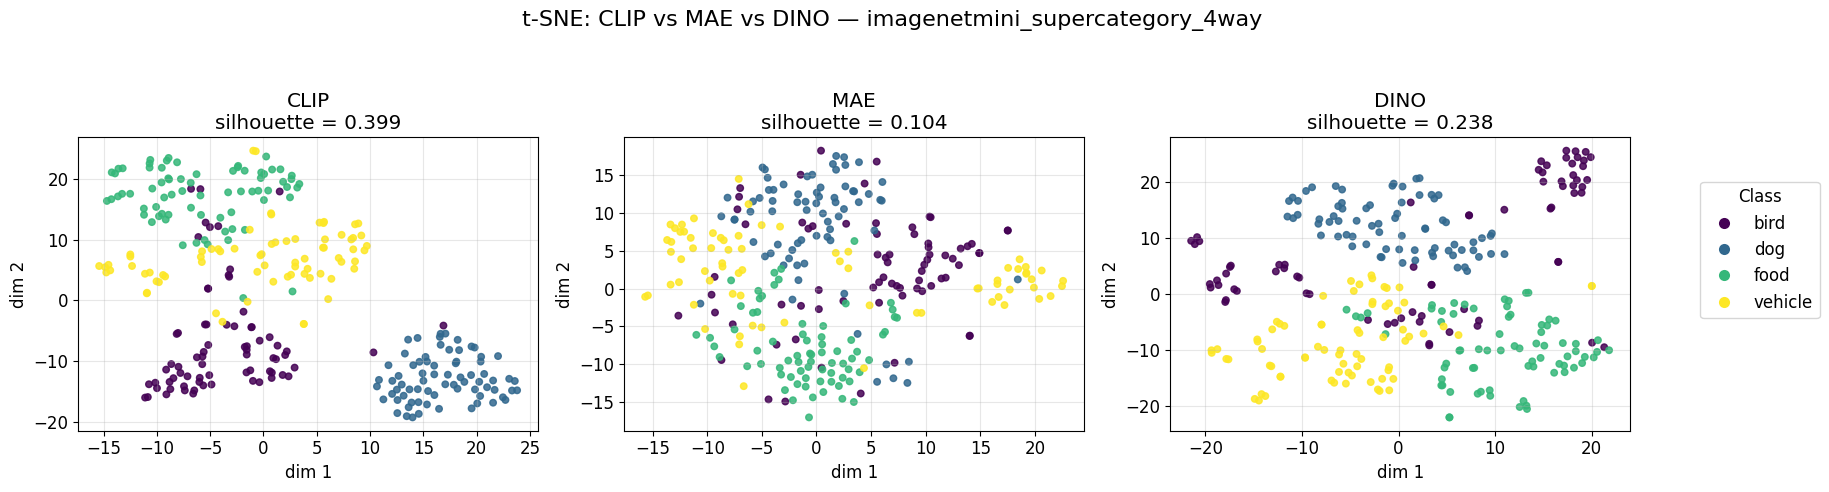

In [ ]:
# ============================================================
# t-SNE
# ============================================================

def run_tsne(features, perplexity=30, pca_dim=50, n_iter=2000):
    x = StandardScaler().fit_transform(features)

    pca_dim = min(pca_dim, x.shape[1], x.shape[0] - 1)
    x_pca = PCA(n_components=pca_dim, random_state=RANDOM_STATE).fit_transform(x)

    # Works across sklearn versions
    try:
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            metric="euclidean",
            random_state=RANDOM_STATE,
            max_iter=n_iter,
        )
    except TypeError:
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            metric="euclidean",
            random_state=RANDOM_STATE,
            n_iter=n_iter,
        )

    z = tsne.fit_transform(x_pca)
    return z


tsne_embeddings = {}

for model_name, feats in features_by_model.items():
    print(f"Running t-SNE for {model_name}")
    tsne_embeddings[model_name] = run_tsne(
        feats,
        perplexity=30,
        pca_dim=50,
        n_iter=2000,
    )

plot_2d_embeddings_grid(
    tsne_embeddings,
    viz_labels,
    title=f"t-SNE: CLIP vs MAE vs DINO — {VIZ_CONCEPT_NAME}",
    class_names=VIZ_CLASS_NAMES,
    save_path=f"results/{VIZ_CONCEPT_NAME}_tsne_clip_mae_dino.png",
)